<a href="https://colab.research.google.com/github/gopichand909/Real-Time-Order-Batching-Rider-Dispatch-Optimization/blob/main/main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [36]:
import numpy as np
import pandas as pd
from datetime import datetime, timedelta

# Set seed for benchmarking consistency
np.random.seed(42)

# BENGALURU PINCODE ZONES
BENGALURU_DATA = {
    "Koramangala": (12.9352, 77.6245, 0.40), "Indiranagar": (12.9719, 77.6412, 0.35),
    "HSR Layout": (12.9121, 77.6446, 0.30), "Whitefield": (12.9698, 77.7500, 0.25),
    "BTM Layout": (12.9166, 77.6101, 0.25), "Jayanagar": (12.9299, 77.5848, 0.20),
    "JP Nagar": (12.9063, 77.5857, 0.20), "MG Road": (12.9738, 77.6119, 0.20),
    "Malleshwaram": (12.9982, 77.5703, 0.15), "Rajajinagar": (12.9901, 77.5525, 0.15),
    "Frazer Town": (12.9975, 77.6144, 0.10), "Hebbal": (13.0354, 77.5988, 0.10),
    "Electronic City": (12.8452, 77.6632, 0.20), "Marathahalli": (12.9569, 77.7011, 0.25),
    "Bellandur": (12.9304, 77.6784, 0.30), "Bannerghatta Rd": (12.8907, 77.5953, 0.15),
    "Ulsoor": (12.9817, 77.6284, 0.15), "Domlur": (12.9610, 77.6387, 0.15),
    "Vasanth Nagar": (12.9880, 77.5885, 0.10), "Richmond Town": (12.9647, 77.5966, 0.10),
    "Kalyan Nagar": (13.0221, 77.6403, 0.10), "Banashankari": (12.9254, 77.5468, 0.10),
    "Basavanagudi": (12.9417, 77.5755, 0.10), "AECS Layout": (12.9615, 77.7135, 0.15),
    "CV Raman Nagar": (12.9793, 77.6642, 0.10), "Cooke Town": (13.0012, 77.6256, 0.05),
    "Yeswanthpur": (13.0235, 77.5550, 0.10), "Kengeri": (12.9038, 77.4833, 0.05),
    "Banaswadi": (13.0104, 77.6482, 0.10), "Sadashiva Nagar": (13.0068, 77.5813, 0.05)
}

def haversine(lat1, lon1, lat2, lon2):
    R = 6371.0
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    dphi, dlambda = np.radians(lat2 - lat1), np.radians(lon2 - lon1)
    a = np.sin(dphi/2)**2 + np.cos(phi1) * np.cos(phi2) * np.sin(dlambda/2)**2
    return 2 * R * np.arcsin(np.sqrt(a))

# --- SIMULATION PARAMETERS ---
sim_start_time = datetime(2026, 4, 14, 19, 0)
duration_min = 180
lambda_ph = 150 # FIX: Reduced from 1200 to 150 for realistic normal load
total_riders = 1000

# --- 1. GENERATING ORDERS (3 HOURS) ---
zones = list(BENGALURU_DATA.keys())
weights = [BENGALURU_DATA[z][2] for z in zones]
weights = [w/sum(weights) for w in weights]

order_list = []
t_curr = 0
while t_curr < duration_min:
    t_curr += np.random.exponential(60 / lambda_ph)
    if t_curr > duration_min: break
    z_name = np.random.choice(zones, p=weights)
    b_lat, b_lon, _ = BENGALURU_DATA[z_name]
    order_list.append({
        "order_id": len(order_list)+1, "zone": z_name,
        "dest_lat": b_lat + np.random.uniform(-0.01, 0.01),
        "dest_lon": b_lon + np.random.uniform(-0.01, 0.01),
        "arrival_time": sim_start_time + timedelta(minutes=t_curr),
        "batch_window": int(t_curr // 3)
    })
orders_df = pd.DataFrame(order_list)

# --- 2. GENERATING DYNAMIC RIDERS ---
rider_list = []
for i in range(total_riders):
    z = np.random.choice(zones)
    login_offset_min = 0 if np.random.rand() < 0.40 else np.random.uniform(0, 120)
    shift_duration_min = np.random.uniform(90, 240)
    login_time = sim_start_time + timedelta(minutes=login_offset_min)

    rider_list.append({
        "rider_id": f"R-{i+1:04d}", "lat": BENGALURU_DATA[z][0], "lon": BENGALURU_DATA[z][1],
        "capacity": np.random.choice([2, 3]), "available_at": login_time,
        "logout_at": login_time + timedelta(minutes=shift_duration_min), "total_dist": 0.0
    })
riders_df = pd.DataFrame(rider_list)

print(f"--- DATA GENERATION COMPLETE ---")
print(f"Total Orders Generated: {len(orders_df)}")
print(f"Total Unique Riders: {len(riders_df)}")

--- DATA GENERATION COMPLETE ---
Total Orders Generated: 435
Total Unique Riders: 1000


In [37]:
riders_df

,rider_id,lat,lon,capacity,available_at,logout_at,total_dist
0,R-0001,12.9166,77.6101,2,2026-04-14 19:00:00.000000,2026-04-14 22:54:34.400479,0.0
1,R-0002,12.9719,77.6412,3,2026-04-14 19:00:00.000000,2026-04-14 21:32:47.225595,0.0
2,R-0003,12.9304,77.6784,2,2026-04-14 20:21:43.018756,2026-04-14 22:20:10.272390,0.0
3,R-0004,12.9352,77.6245,2,2026-04-14 19:00:00.000000,2026-04-14 22:35:08.730294,0.0
4,R-0005,13.0221,77.6403,3,2026-04-14 19:00:00.000000,2026-04-14 20:39:41.550119,0.0
...,...,...,...,...,...,...,...
995,R-0996,12.9698,77.7500,3,2026-04-14 20:42:23.883744,2026-04-14 23:27:08.880999,0.0
996,R-0997,13.0104,77.6482,3,2026-04-14 19:00:00.000000,2026-04-14 21:51:34.083634,0.0
997,R-0998,12.9166,77.6101,2,2026-04-14 20:58:50.053228,2026-04-15 00:00:32.128134,0.0
998,R-0999,13.0068,77.5813,2,2026-04-14 19:20:27.330083,2026-04-14 21:48:07.972406,0.0


In [38]:
orders_df

,order_id,zone,dest_lat,dest_lon,arrival_time,batch_window
0,1,Yeswanthpur,13.028140,77.556973,2026-04-14 19:00:11.262434,0
1,2,HSR Layout,12.903262,77.651924,2026-04-14 19:00:15.333431,0
2,3,Bannerghatta Rd,12.881112,77.604698,2026-04-14 19:00:37.391403,0
3,4,Whitefield,12.963436,77.743668,2026-04-14 19:01:20.265712,0
4,5,Hebbal,13.034039,77.594625,2026-04-14 19:01:28.971801,0
...,...,...,...,...,...,...
430,431,Indiranagar,12.967966,77.633221,2026-04-14 21:57:54.795650,59
431,432,Koramangala,12.935388,77.634434,2026-04-14 21:58:23.071957,59
432,433,Marathahalli,12.953025,77.703578,2026-04-14 21:59:03.436328,59
433,434,MG Road,12.966414,77.619632,2026-04-14 21:59:21.406269,59


In [39]:
def run_baseline_simulation(orders, riders):
    # Working on copies to preserve original data
    fleet = riders.copy()
    results = []
    avg_speed = 20 # km/h
    service_time = 5 # minutes (pickup + dropoff)

    for _, order in orders.sort_values('arrival_time').iterrows():
        # 1. Identify Pickup Point (Zone Center)
        pickup_lat, pickup_lon, _ = BENGALURU_DATA[order['zone']]

        # 2. Find Nearest Rider (currently available or soonest available)
        # We calculate distance from rider's LAST location to the pickup point
        fleet['dist_to_pickup'] = fleet.apply(
            lambda r: haversine(r['lat'], r['lon'], pickup_lat, pickup_lon), axis=1
        )

        # In baseline, we pick the rider who can reach the restaurant fastest
        best_idx = fleet['dist_to_pickup'].idxmin()
        rider = fleet.loc[best_idx]

        # 3. Calculate Distance Legs
        dist_to_pickup = rider['dist_to_pickup']
        dist_to_dest = haversine(pickup_lat, pickup_lon, order['dest_lat'], order['dest_lon'])
        trip_dist = dist_to_pickup + dist_to_dest

        # 4. Calculate Timing
        travel_time_min = (trip_dist / avg_speed) * 60
        # Rider starts either when order arrives OR when they finish their previous task
        start_time = max(order['arrival_time'], rider['available_at'])
        completion_time = start_time + timedelta(minutes=travel_time_min + service_time)

        # 5. Update Rider State (Fact: They are now at the customer's house)
        fleet.at[best_idx, 'lat'] = order['dest_lat']
        fleet.at[best_idx, 'lon'] = order['dest_lon']
        fleet.at[best_idx, 'available_at'] = completion_time
        fleet.at[best_idx, 'total_dist'] += trip_dist

        # 6. Log Metrics
        # SLA is measured from Arrival Time to Completion Time
        total_duration = (completion_time - order['arrival_time']).total_seconds() / 60
        results.append({
            "order_id": order['order_id'],
            "duration": total_duration,
            "dist": trip_dist,
            "sla_success": total_duration <= 15
        })

    return pd.DataFrame(results), fleet

# EXECUTION
baseline_results, final_fleet = run_baseline_simulation(orders_df, riders_df)

print(f"--- BASELINE METRICS ---")
print(f"Avg Delivery Time: {baseline_results['duration'].mean():.2f} min")
print(f"SLA Success Rate: {baseline_results['sla_success'].mean()*100:.1f}%")
print(f"Total Fleet Distance: {final_fleet['total_dist'].sum():.2f} km")

--- BASELINE METRICS ---
Avg Delivery Time: 15.53 min
SLA Success Rate: 81.6%
Total Fleet Distance: 368.15 km


In [40]:
import numpy as np
import pandas as pd
from datetime import timedelta

def run_step3_batching(orders, riders):
    fleet = riders.copy()
    results = []
    avg_speed = 20  # km/h
    service_time_per_stop = 5  # minutes

    # Sort orders by arrival time to simulate a real-time queue
    orders = orders.sort_values('arrival_time').reset_index(drop=True)
    processed_indices = set()

    for i in range(len(orders)):
        if i in processed_indices:
            continue

        order = orders.iloc[i]

        # --- 1. FORM THE BATCH ---
        batch = [order]
        processed_indices.add(i)

        # Constraint: Orders must arrive within 3 minutes of the first order
        time_limit = order['arrival_time'] + timedelta(minutes=3)

        # Look ahead for potential batch mates
        for j in range(i + 1, len(orders)):
            pot_order = orders.iloc[j]

            if pot_order['arrival_time'] > time_limit:
                break  # Outside the 3-minute window

            if j in processed_indices:
                continue

            if len(batch) >= 3:
                break  # Capacity limit reached

            # Constraint: Must be within 1.5 km of the primary order's destination
            dist = haversine(
                order['dest_lat'], order['dest_lon'],
                pot_order['dest_lat'], pot_order['dest_lon']
            )

            if dist <= 1.5:
                batch.append(pot_order)
                processed_indices.add(j)

        # --- 2. FIND NEAREST AVAILABLE RIDER ---
        batch_ready_time = max([b['arrival_time'] for b in batch])
        pickup_lat, pickup_lon, _ = BENGALURU_DATA[order['zone']]

        # Filter for riders available right now
        avail_mask = fleet['available_at'] <= batch_ready_time

        if not avail_mask.any():
            # Edge Case: If no one is free, pick the rider who frees up next
            best_idx = fleet['available_at'].idxmin()
        else:
            # Pick the closest rider among those currently available
            avail_fleet = fleet[avail_mask].copy()
            avail_fleet['dist_to_pickup'] = avail_fleet.apply(
                lambda r: haversine(r['lat'], r['lon'], pickup_lat, pickup_lon), axis=1
            )
            best_idx = avail_fleet['dist_to_pickup'].idxmin()

        rider = fleet.loc[best_idx]

        # --- 3. CALCULATE DISTANCE AND TIME ---
        dist_to_pickup = haversine(rider['lat'], rider['lon'], pickup_lat, pickup_lon)

        # Step 3 Simplification: Distance to the furthest drop in the batch
        furthest_drop = max([haversine(pickup_lat, pickup_lon, b['dest_lat'], b['dest_lon']) for b in batch])

        total_trip_dist = dist_to_pickup + furthest_drop
        total_travel_time = (total_trip_dist / avg_speed) * 60
        total_service_time = len(batch) * service_time_per_stop

        start_time = max(batch_ready_time, rider['available_at'])
        completion_time = start_time + timedelta(minutes=total_travel_time + total_service_time)

        # --- 4. UPDATE RIDER STATE ---
        last_drop = batch[-1]
        fleet.at[best_idx, 'lat'] = last_drop['dest_lat']
        fleet.at[best_idx, 'lon'] = last_drop['dest_lon']
        fleet.at[best_idx, 'available_at'] = completion_time
        fleet.at[best_idx, 'total_dist'] += total_trip_dist

        # --- 5. LOG METRICS ---
        for b in batch:
            dur = (completion_time - b['arrival_time']).total_seconds() / 60
            results.append({
                "order_id": b['order_id'],
                "duration": dur,
                "dist": total_trip_dist / len(batch), # Apportioned distance per order
                "sla_success": dur <= 15
            })

    return pd.DataFrame(results), fleet

# --- EXECUTION & OUTPUT ---
batch_results, batch_fleet = run_step3_batching(orders_df, riders_df)

print(f"--- STEP 3: BASIC BATCHING METRICS ---")
print(f"Avg Delivery Time: {batch_results['duration'].mean():.2f} min")
print(f"SLA Success Rate (15m): {batch_results['sla_success'].mean()*100:.1f}%")
print(f"Total Fleet Distance: {batch_fleet['total_dist'].sum():.2f} km")

--- STEP 3: BASIC BATCHING METRICS ---
Avg Delivery Time: 10.88 min
SLA Success Rate (15m): 79.5%
Total Fleet Distance: 321.51 km


In [41]:
import time
import pandas as pd
import numpy as np
from datetime import timedelta
from scipy.optimize import linear_sum_assignment

# --- OPTIMIZATION 1: Vectorized Haversine ---
def vectorized_haversine(lat1, lon1, lat2, lon2):
    R = 6371.0
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    dphi, dlambda = np.radians(lat2 - lat1), np.radians(lon2 - lon1)
    a = np.sin(dphi/2.0)**2 + np.cos(phi1) * np.cos(phi2) * np.sin(dlambda/2.0)**2
    return 2 * R * np.arcsin(np.sqrt(a))

def run_optimized_assignment_simulation(orders, riders, strategy='greedy'):
    fleet = riders.copy()
    results = []
    avg_speed = 20  # km/h
    service_time_per_stop = 5  # minutes

    # NEW TRACKERS
    total_assignment_time = 0.0
    total_assignment_cost = 0.0

    max_window = orders['batch_window'].max()

    for window in range(max_window + 1):
        window_orders = orders[orders['batch_window'] == window]
        if window_orders.empty: continue

        # --- 1. BATCH FORMATION ---
        processed = set()
        batches = []
        for order in window_orders.itertuples():
            if order.Index in processed: continue
            batch = [{
                'order_id': order.order_id, 'zone': order.zone,
                'dest_lat': order.dest_lat, 'dest_lon': order.dest_lon,
                'arrival_time': order.arrival_time
            }]
            processed.add(order.Index)

            for pot_order in window_orders.itertuples():
                if pot_order.Index in processed: continue
                if len(batch) >= 3: break

                dist = vectorized_haversine(
                    order.dest_lat, order.dest_lon,
                    pot_order.dest_lat, pot_order.dest_lon
                )
                if dist <= 1.5:
                    batch.append({
                        'order_id': pot_order.order_id, 'zone': pot_order.zone,
                        'dest_lat': pot_order.dest_lat, 'dest_lon': pot_order.dest_lon,
                        'arrival_time': pot_order.arrival_time
                    })
                    processed.add(pot_order.Index)
            batches.append(batch)

        if not batches: continue
        cycle_time = window_orders['arrival_time'].max()

        # --- 2. GET AVAILABLE RIDERS ---
        available_riders = fleet[fleet['available_at'] <= cycle_time]
        if len(available_riders) < len(batches):
            available_riders = fleet.nsmallest(len(batches), 'available_at')

        # --- 3. BATCH-TO-RIDER ASSIGNMENT (WITH INSTRUMENTATION) ---
        assignments = []
        r_indices = available_riders.index.to_numpy()
        r_lats = available_riders['lat'].to_numpy()
        r_lons = available_riders['lon'].to_numpy()

        # START TIMER
        t0 = time.perf_counter()

        if strategy == 'greedy':
            # OPTIMIZED GREEDY: Vectorized Boolean Masking
            available_mask = np.ones(len(r_indices), dtype=bool)

            for b_idx, batch in enumerate(batches):
                p_lat, p_lon, _ = BENGALURU_DATA[batch[0]['zone']]
                dists = vectorized_haversine(p_lat, p_lon, r_lats, r_lons)

                # Apply mask instantly in C++ via NumPy
                masked_dists = np.where(available_mask, dists, np.inf)

                best_i = np.argmin(masked_dists)
                if masked_dists[best_i] != np.inf:
                    best_r_idx = r_indices[best_i]
                    assignments.append((b_idx, best_r_idx))
                    available_mask[best_i] = False # Mark rider as taken

        elif strategy == 'hungarian':
            b_lats = np.array([BENGALURU_DATA[b[0]['zone']][0] for b in batches]).reshape(-1, 1)
            b_lons = np.array([BENGALURU_DATA[b[0]['zone']][1] for b in batches]).reshape(-1, 1)
            cost_matrix = vectorized_haversine(b_lats, b_lons, r_lats.reshape(1, -1), r_lons.reshape(1, -1))
            row_ind, col_ind = linear_sum_assignment(cost_matrix)
            for i in range(len(row_ind)):
                assignments.append((row_ind[i], r_indices[col_ind[i]]))

        # STOP TIMER
        t1 = time.perf_counter()
        total_assignment_time += (t1 - t0)

        # LOG ASSIGNMENT COST (Distance from Rider to Pickup)
        for b_idx, r_idx in assignments:
            p_lat, p_lon, _ = BENGALURU_DATA[batches[b_idx][0]['zone']]
            r_lat = fleet.at[r_idx, 'lat']
            r_lon = fleet.at[r_idx, 'lon']
            total_assignment_cost += vectorized_haversine(r_lat, r_lon, p_lat, p_lon)

        # --- 4. DISPATCH AND LOG METRICS ---
        for b_idx, r_idx in assignments:
            batch = batches[b_idx]

            rider_lat = fleet.at[r_idx, 'lat']
            rider_lon = fleet.at[r_idx, 'lon']
            rider_avail = fleet.at[r_idx, 'available_at']

            pickup_lat, pickup_lon, _ = BENGALURU_DATA[batch[0]['zone']]
            dist_to_pickup = vectorized_haversine(rider_lat, rider_lon, pickup_lat, pickup_lon)
            furthest_drop_dist = max([vectorized_haversine(pickup_lat, pickup_lon, b['dest_lat'], b['dest_lon']) for b in batch])
            total_trip_dist = dist_to_pickup + furthest_drop_dist

            total_travel_time = (total_trip_dist / avg_speed) * 60
            total_service_time = len(batch) * service_time_per_stop

            batch_ready_time = max([b['arrival_time'] for b in batch])
            start_time = max(batch_ready_time, rider_avail, cycle_time)
            completion_time = start_time + timedelta(minutes=total_travel_time + total_service_time)

            fleet.at[r_idx, 'lat'] = batch[-1]['dest_lat']
            fleet.at[r_idx, 'lon'] = batch[-1]['dest_lon']
            fleet.at[r_idx, 'available_at'] = completion_time
            fleet.at[r_idx, 'total_dist'] += total_trip_dist

            for b in batch:
                dur = (completion_time - b['arrival_time']).total_seconds() / 60
                results.append({
                    "order_id": b['order_id'], "duration": dur,
                    "dist": total_trip_dist / len(batch), "sla_success": dur <= 15
                })

    return pd.DataFrame(results), fleet, total_assignment_time, total_assignment_cost

# --- 5. EXECUTION & OUTPUT ---
print("Running Fast Greedy Assignment Simulation...")
g_res, g_fleet, g_time, g_cost = run_optimized_assignment_simulation(orders_df, riders_df, strategy='greedy')

print("Running Fast Hungarian Assignment Simulation...")
h_res, h_fleet, h_time, h_cost = run_optimized_assignment_simulation(orders_df, riders_df, strategy='hungarian')

def print_metrics(name, res, fleet, assign_time, assign_cost):
    print(f"\n--- {name} METRICS ---")
    print(f"Avg Delivery Time:    {res['duration'].mean():.2f} min")
    print(f"SLA Success Rate:     {res['sla_success'].mean()*100:.1f}%")
    print(f"Total Assignment Cost:{assign_cost:.2f} km (Deadhead Distance)")
    print(f"Total Algorithm Time: {assign_time*1000:.2f} ms")

print_metrics("GREEDY (O(B x R))", g_res, g_fleet, g_time, g_cost)
print_metrics("HUNGARIAN (Global Opt)", h_res, h_fleet, h_time, h_cost)


# --- 6. ISOLATED SURGE STRESS TEST ---
print("\n" + "="*50)
print("ALGORITHM STRESS TEST: SURGE CONDITIONS")
print("="*50)

def surge_stress_test(num_batches, num_riders):
    # Generate random coordinates for batches and riders
    b_lats = np.random.uniform(12.8, 13.1, (num_batches, 1))
    b_lons = np.random.uniform(77.5, 77.8, (num_batches, 1))
    r_lats = np.random.uniform(12.8, 13.1, (1, num_riders))
    r_lons = np.random.uniform(77.5, 77.8, (1, num_riders))

    # Pre-compute the full cost matrix for BOTH algorithms to ensure fairness
    cost_matrix = vectorized_haversine(b_lats, b_lons, r_lats, r_lons)

    # 1. Hungarian Time
    t0 = time.perf_counter()
    row_ind, col_ind = linear_sum_assignment(cost_matrix)
    t1 = time.perf_counter()
    hungarian_time = (t1 - t0) * 1000

    # 2. OPTIMIZED Greedy Time
    t0 = time.perf_counter()
    available_mask = np.ones(num_riders, dtype=bool)

    for b_idx in range(num_batches):
        row_costs = cost_matrix[b_idx, :]
        masked_costs = np.where(available_mask, row_costs, np.inf)
        best_r = np.argmin(masked_costs)
        available_mask[best_r] = False

    t1 = time.perf_counter()
    greedy_time = (t1 - t0) * 1000

    print(f"Load: {num_batches} Batches, {num_riders} Available Riders")
    print(f"Greedy Time:    {greedy_time:.2f} ms")
    print(f"Hungarian Time: {hungarian_time:.2f} ms\n")

# Normal Load
surge_stress_test(10, 50)
# Surge Load
surge_stress_test(80, 200)
# Extreme Surge
surge_stress_test(200, 500)
# The Breaking Point Tests
surge_stress_test(500, 1500)
surge_stress_test(1000, 3000)
surge_stress_test(2000, 5000)

Running Fast Greedy Assignment Simulation...
Running Fast Hungarian Assignment Simulation...

--- GREEDY (O(B x R)) METRICS ---
Avg Delivery Time:    10.19 min
SLA Success Rate:     90.1%
Total Assignment Cost:0.00 km (Deadhead Distance)
Total Algorithm Time: 44.06 ms

--- HUNGARIAN (Global Opt) METRICS ---
Avg Delivery Time:    10.19 min
SLA Success Rate:     90.1%
Total Assignment Cost:0.00 km (Deadhead Distance)
Total Algorithm Time: 32.83 ms

ALGORITHM STRESS TEST: SURGE CONDITIONS
Load: 10 Batches, 50 Available Riders
Greedy Time:    0.14 ms
Hungarian Time: 0.03 ms

Load: 80 Batches, 200 Available Riders
Greedy Time:    0.71 ms
Hungarian Time: 0.29 ms

Load: 200 Batches, 500 Available Riders
Greedy Time:    1.80 ms
Hungarian Time: 1.62 ms

Load: 500 Batches, 1500 Available Riders
Greedy Time:    6.01 ms
Hungarian Time: 12.05 ms

Load: 1000 Batches, 3000 Available Riders
Greedy Time:    17.30 ms
Hungarian Time: 49.10 ms

Load: 2000 Batches, 5000 Available Riders
Greedy Time:    57.

In [42]:
import time
import itertools
import requests
import numpy as np

# =============================================================================
# 1. DISTANCE METRICS (Haversine & OSRM)
# =============================================================================
def scalar_haversine(lat1, lon1, lat2, lon2):
    """Fast, local CPU calculation for geometric distance."""
    R = 6371.0
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    dphi, dlambda = np.radians(lat2 - lat1), np.radians(lon2 - lon1)
    a = np.sin(dphi/2.0)**2 + np.cos(phi1) * np.cos(phi2) * np.sin(dlambda/2.0)**2
    return 2 * R * np.arcsin(np.sqrt(a))

# In-memory dictionary to store previously calculated OSRM distances
distance_cache = {}

def get_osrm_distance(lat1, lon1, lat2, lon2):
    """Fetches real road distance from OSRM with caching and silent fallback."""
    cache_key = f"{lat1:.4f},{lon1:.4f}-{lat2:.4f},{lon2:.4f}"

    # 1. Check Cache
    if cache_key in distance_cache:
        return distance_cache[cache_key]

    # 2. Call OSRM API (Longitude, Latitude order!)
    url = f"http://router.project-osrm.org/route/v1/driving/{lon1},{lat1};{lon2},{lat2}?overview=false"

    try:
        response = requests.get(url, timeout=1.0)
        if response.status_code == 200:
            dist_km = response.json()['routes'][0]['distance'] / 1000.0
            distance_cache[cache_key] = dist_km
            return dist_km
    except requests.RequestException:
        pass # Silently catch timeouts/errors

    # 3. Silent Fallback (Haversine * 1.3 to estimate urban road grid)
    fallback_dist = scalar_haversine(lat1, lon1, lat2, lon2) * 1.3
    distance_cache[cache_key] = fallback_dist
    return fallback_dist


def calc_route_dist(pickup_lat, pickup_lon, route, dist_func):
    """Calculates total continuous distance: Pickup -> Drop 1 -> ... -> Drop N"""
    if not route: return 0.0
    dist = dist_func(pickup_lat, pickup_lon, route[0]['dest_lat'], route[0]['dest_lon'])
    for i in range(len(route) - 1):
        dist += dist_func(route[i]['dest_lat'], route[i]['dest_lon'],
                          route[i+1]['dest_lat'], route[i+1]['dest_lon'])
    return dist

# =============================================================================
# 2. INTRA-BATCH ROUTING ALGORITHMS
# =============================================================================
def route_nn(pickup_lat, pickup_lon, batch, dist_func):
    """Nearest Neighbor Heuristic: O(N^2)"""
    route = []
    unvisited = batch.copy()
    curr_lat, curr_lon = pickup_lat, pickup_lon
    while unvisited:
        best_idx = min(range(len(unvisited)),
                       key=lambda i: dist_func(curr_lat, curr_lon, unvisited[i]['dest_lat'], unvisited[i]['dest_lon']))
        nxt = unvisited.pop(best_idx)
        route.append(nxt)
        curr_lat, curr_lon = nxt['dest_lat'], nxt['dest_lon']
    return route, calc_route_dist(pickup_lat, pickup_lon, route, dist_func)

def route_nn_2opt(pickup_lat, pickup_lon, batch, dist_func):
    """NN + 2-Opt Local Search"""
    route, best_dist = route_nn(pickup_lat, pickup_lon, batch, dist_func)
    if len(route) <= 2: return route, best_dist

    improved = True
    while improved:
        improved = False
        for i in range(len(route) - 1):
            for j in range(i + 1, len(route)):
                new_route = route[:i] + route[i:j+1][::-1] + route[j+1:]
                new_dist = calc_route_dist(pickup_lat, pickup_lon, new_route, dist_func)
                if new_dist < best_dist - 1e-5:
                    best_dist = new_dist
                    route = new_route
                    improved = True
    return route, best_dist

def route_brute_force(pickup_lat, pickup_lon, batch, dist_func):
    """Exact Brute Force Search: O(N!)"""
    if len(batch) <= 1:
        return batch, calc_route_dist(pickup_lat, pickup_lon, batch, dist_func)

    best_route, best_dist = None, float('inf')
    for p in itertools.permutations(batch):
        dist = calc_route_dist(pickup_lat, pickup_lon, p, dist_func)
        if dist < best_dist:
            best_dist, best_route = dist, list(p)
    return best_route, best_dist

# =============================================================================
# 3. ALGORITHM CPU BENCHMARK
# =============================================================================
def benchmark_routing_algorithms():
    print("\n" + "="*50)
    print("STEP 5: ALGORITHM CPU BENCHMARK (Using Haversine)")
    print("="*50)

    num_tests = 5000
    p_lat, p_lon = 12.9352, 77.6245
    test_batches = [[{'id': i, 'dest_lat': p_lat + np.random.uniform(-0.05, 0.05), 'dest_lon': p_lon + np.random.uniform(-0.05, 0.05)} for i in range(3)] for _ in range(num_tests)]

    # We pass `scalar_haversine` here to test pure CPU speed without network latency
    t0 = time.perf_counter()
    nn_dist = sum(route_nn(p_lat, p_lon, b, scalar_haversine)[1] for b in test_batches)
    t_nn = (time.perf_counter() - t0) * 1000

    t0 = time.perf_counter()
    opt_dist = sum(route_nn_2opt(p_lat, p_lon, b, scalar_haversine)[1] for b in test_batches)
    t_opt = (time.perf_counter() - t0) * 1000

    t0 = time.perf_counter()
    bf_dist = sum(route_brute_force(p_lat, p_lon, b, scalar_haversine)[1] for b in test_batches)
    t_bf = (time.perf_counter() - t0) * 1000

    print(f"Tested on {num_tests} random batches of size 3.")
    print(f"{'Algorithm':<15} | {'Total Distance (km)':<20} | {'CPU Time (ms)':<10}")
    print("-" * 50)
    print(f"{'Nearest N.':<15} | {nn_dist:<20.2f} | {t_nn:.2f}")
    print(f"{'NN + 2-Opt':<15} | {opt_dist:<20.2f} | {t_opt:.2f}")
    print(f"{'Brute Force':<15} | {bf_dist:<20.2f} | {t_bf:.2f}")
    print("\nConclusion: For N<=3, Brute Force is computationally trivial and guarantees optimal routing.")

# Run the benchmark
benchmark_routing_algorithms()

# =============================================================================
# 4. PRODUCTION USAGE EXAMPLE
# =============================================================================
# When integrating this into your main dispatch loop (Step 6), you will call:
# best_route, real_road_dist = route_brute_force(pickup_lat, pickup_lon, batch, get_osrm_distance)


STEP 5: ALGORITHM CPU BENCHMARK (Using Haversine)
Tested on 5000 random batches of size 3.
Algorithm       | Total Distance (km)  | CPU Time (ms)
--------------------------------------------------
Nearest N.      | 67005.06             | 558.43
NN + 2-Opt      | 65199.17             | 1163.55
Brute Force     | 64895.36             | 1020.25

Conclusion: For N<=3, Brute Force is computationally trivial and guarantees optimal routing.


In [46]:
import time
import itertools
import pandas as pd
import numpy as np
from datetime import timedelta
from scipy.optimize import linear_sum_assignment

# --- 1. DISTANCE METRICS (Haversine Only) ---
def vectorized_haversine(lat1, lon1, lat2, lon2):
    """Fast NumPy calculation for the Assignment Matrix (Step 4)"""
    R = 6371.0
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    dphi, dlambda = np.radians(lat2 - lat1), np.radians(lon2 - lon1)
    a = np.sin(dphi/2.0)**2 + np.cos(phi1) * np.cos(phi2) * np.sin(dlambda/2.0)**2
    return 2 * R * np.arcsin(np.sqrt(a))

def scalar_haversine(lat1, lon1, lat2, lon2):
    """Single-value calculation for intra-batch routing and simple checks"""
    R = 6371.0
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    dphi, dlambda = np.radians(lat2 - lat1), np.radians(lon2 - lon1)
    a = np.sin(dphi/2.0)**2 + np.cos(phi1) * np.cos(phi2) * np.sin(dlambda/2.0)**2
    return 2 * R * np.arcsin(np.sqrt(a))

# --- 2. INTRA-BATCH ROUTING (Step 5 - Haversine) ---
def route_brute_force(pickup_lat, pickup_lon, batch):
    """Finds the shortest dropoff sequence using Haversine distance"""
    if len(batch) <= 1:
        dist = scalar_haversine(pickup_lat, pickup_lon, batch[0]['dest_lat'], batch[0]['dest_lon'])
        return batch, dist

    best_route, best_dist = None, float('inf')
    for p in itertools.permutations(batch):
        dist = scalar_haversine(pickup_lat, pickup_lon, p[0]['dest_lat'], p[0]['dest_lon'])
        for i in range(len(p) - 1):
            dist += scalar_haversine(p[i]['dest_lat'], p[i]['dest_lon'], p[i+1]['dest_lat'], p[i+1]['dest_lon'])
        if dist < best_dist:
            best_dist, best_route = dist, list(p)
    return best_route, best_dist

# --- 3. REAL-TIME EVENT LOOP (Step 6) ---
def run_realtime_simulation(orders, riders):
    fleet = riders.copy()
    results = []

    avg_speed = 20 # km/h
    service_time_per_stop = 5 # mins

    # Sort orders chronologically
    orders = orders.sort_values('arrival_time').reset_index(drop=True)

    # Initialize Simulation Clock
    current_time = orders['arrival_time'].min()
    dispatched_order_ids = set()
    total_orders = len(orders)

    while len(dispatched_order_ids) < total_orders:

        # 1. PULL PENDING QUEUE
        pending_orders = orders[(orders['arrival_time'] <= current_time) & (~orders['order_id'].isin(dispatched_order_ids))]
        if pending_orders.empty:
            current_time += timedelta(minutes=1)
            continue

        # 2. GET AVAILABLE RIDERS
        available_riders = fleet[fleet['available_at'] <= current_time]
        if available_riders.empty:
            current_time += timedelta(minutes=1)
            continue

        # 3. REAL-TIME BATCHING
        batches = []
        processed_in_cycle = set()

        for i, order in pending_orders.iterrows():
            if order['order_id'] in processed_in_cycle: continue

            batch = [{'order_id': order['order_id'], 'zone': order['zone'],
                      'dest_lat': order['dest_lat'], 'dest_lon': order['dest_lon'],
                      'arrival_time': order['arrival_time']}]
            processed_in_cycle.add(order['order_id'])

            for j, pot_order in pending_orders.iterrows():
                if pot_order['order_id'] in processed_in_cycle: continue
                if len(batch) >= 3: break

                # 3-minute max wait time from first order in batch
                if (pot_order['arrival_time'] - batch[0]['arrival_time']).total_seconds() / 60 > 3:
                    continue

                # Use Haversine for fast geometric grouping
                dist = scalar_haversine(order['dest_lat'], order['dest_lon'], pot_order['dest_lat'], pot_order['dest_lon'])
                if dist <= 1.5:
                    batch.append({'order_id': pot_order['order_id'], 'zone': pot_order['zone'],
                                  'dest_lat': pot_order['dest_lat'], 'dest_lon': pot_order['dest_lon'],
                                  'arrival_time': pot_order['arrival_time']})
                    processed_in_cycle.add(pot_order['order_id'])

            batches.append(batch)

        # SLA Protection: Oldest batches first if riders are scarce
        if len(batches) > len(available_riders):
            batches = batches[:len(available_riders)]

        # 4. HUNGARIAN ASSIGNMENT (Using fast Vectorized Haversine)
        assignments = []
        r_indices = available_riders.index.to_numpy()
        r_lats = available_riders['lat'].to_numpy()
        r_lons = available_riders['lon'].to_numpy()

        b_lats = np.array([BENGALURU_DATA[b[0]['zone']][0] for b in batches]).reshape(-1, 1)
        b_lons = np.array([BENGALURU_DATA[b[0]['zone']][1] for b in batches]).reshape(-1, 1)

        cost_matrix = vectorized_haversine(b_lats, b_lons, r_lats.reshape(1, -1), r_lons.reshape(1, -1))
        row_ind, col_ind = linear_sum_assignment(cost_matrix)

        for i in range(len(row_ind)):
            assignments.append((row_ind[i], r_indices[col_ind[i]]))

        # 5. INTRA-BATCH ROUTING & DISPATCH (Haversine Only)
        for b_idx, r_idx in assignments:
            batch = batches[b_idx]
            pickup_lat, pickup_lon, _ = BENGALURU_DATA[batch[0]['zone']]

            # Use Haversine for the delivery route distance
            best_route, dropoff_dist = route_brute_force(pickup_lat, pickup_lon, batch)

            # Use Haversine to find the drive time from the Rider to the Restaurant
            dist_to_pickup = scalar_haversine(fleet.at[r_idx, 'lat'], fleet.at[r_idx, 'lon'], pickup_lat, pickup_lon)

            total_trip_dist = dist_to_pickup + dropoff_dist
            total_travel_time = (total_trip_dist / avg_speed) * 60
            total_service_time = len(batch) * service_time_per_stop

            completion_time = current_time + timedelta(minutes=total_travel_time + total_service_time)

            final_drop = best_route[-1]
            fleet.at[r_idx, 'lat'] = final_drop['dest_lat']
            fleet.at[r_idx, 'lon'] = final_drop['dest_lon']
            fleet.at[r_idx, 'available_at'] = completion_time
            fleet.at[r_idx, 'total_dist'] += total_trip_dist

            for b in batch:
                dispatched_order_ids.add(b['order_id'])
                dur = (completion_time - b['arrival_time']).total_seconds() / 60
                results.append({
                    "order_id": b['order_id'],
                    "batch_size": len(batch),
                    "duration": dur,
                    "dist": total_trip_dist / len(batch),
                    "sla_success": dur <= 15
                })

        # 6. TICK THE CLOCK
        current_time += timedelta(minutes=1)

    return pd.DataFrame(results), fleet

# --- EXECUTION ---
print("Running Step 6: Real-Time Discrete Event Simulation (Haversine Only)...")
t0 = time.perf_counter()
realtime_results, realtime_fleet = run_realtime_simulation(orders_df, riders_df)
execution_time = time.perf_counter() - t0

print(f"\n--- REAL-TIME SIMULATION METRICS ---")
print(f"Total Orders Processed: {len(realtime_results)}")
print(f"Simulation Compute Time:{execution_time:.2f} seconds")
print(f"Avg Delivery Time:      {realtime_results['duration'].mean():.2f} min")
print(f"SLA Success Rate:       {realtime_results['sla_success'].mean()*100:.1f}%")
print(f"Average Batch Size:     {realtime_results['batch_size'].mean():.2f} orders/rider")
print(f"Total Fleet Distance:   {realtime_fleet['total_dist'].sum():.2f} km")

Running Step 6: Real-Time Discrete Event Simulation (Haversine Only)...

--- REAL-TIME SIMULATION METRICS ---
Total Orders Processed: 435
Simulation Compute Time:0.58 seconds
Avg Delivery Time:      8.63 min
SLA Success Rate:       95.2%
Average Batch Size:     1.08 orders/rider
Total Fleet Distance:   366.26 km


In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set global visual style for academic/professional presentation
sns.set_theme(style="whitegrid", context="talk")

def generate_final_report(orders_df,
                          res_baseline, fleet_baseline,
                          res_greedy, fleet_greedy, greedy_assign_times, greedy_assign_costs,
                          res_hungarian, fleet_hungarian, hungarian_assign_times, hungarian_assign_costs):

    print("\n" + "="*50)
    print("STEP 7: GENERATING FINAL EVALUATION DASHBOARD")
    print("="*50)

    # ---------------------------------------------------------
    # 1. DATA AGGREGATION & MERGING
    # ---------------------------------------------------------
    zone_mapping = orders_df[['order_id', 'zone']]
    res_baseline = res_baseline.merge(zone_mapping, on='order_id', how='left')
    res_greedy = res_greedy.merge(zone_mapping, on='order_id', how='left')
    res_hungarian = res_hungarian.merge(zone_mapping, on='order_id', how='left')

    strategies = ['Baseline\n(No Batch)', 'Greedy\nBatching', 'Hungarian\nBatching']

    # KPI 1-3: SLA, Duration, Distance
    sla_rates = [
        res_baseline['sla_success'].mean() * 100,
        res_greedy['sla_success'].mean() * 100,
        res_hungarian['sla_success'].mean() * 100
    ]

    avg_times = [
        res_baseline['duration'].mean(),
        res_greedy['duration'].mean(),
        res_hungarian['duration'].mean()
    ]

    total_dists = [
        fleet_baseline['total_dist'].sum(),
        fleet_greedy['total_dist'].sum(),
        fleet_hungarian['total_dist'].sum()
    ]

    # KPI 4: Rider Utilization (% of fleet that moved)
    utilization = [
        (fleet_baseline['total_dist'] > 0).mean() * 100,
        (fleet_greedy['total_dist'] > 0).mean() * 100,
        (fleet_hungarian['total_dist'] > 0).mean() * 100
    ]

    # KPI 5 & 6: Assignment Cost and Runtime (Handling lists/arrays safely)
    algos = ['Greedy', 'Hungarian']
    costs = [np.sum(greedy_assign_costs), np.sum(hungarian_assign_costs)]

    # Use mean() for runtime to show per-cycle speed, convert to milliseconds
    times = [np.mean(greedy_assign_times) * 1000, np.mean(hungarian_assign_times) * 1000]

    # ---------------------------------------------------------
    # 2. PLOTTING THE DASHBOARD
    # ---------------------------------------------------------
    fig, axes = plt.subplots(3, 2, figsize=(18, 18))
    fig.suptitle('Real-Time Order Batching & Dispatch Optimization', fontsize=22, fontweight='bold')

    # Plot 1: SLA Adherence (Bar Chart)
    sns.barplot(x=strategies, y=sla_rates, ax=axes[0, 0], palette=['#e74c3c', '#f1c40f', '#2ecc71'])
    axes[0, 0].set_title('SLA Adherence (< 25 mins)', fontsize=16, fontweight='bold')
    axes[0, 0].set_ylabel('Success Rate (%)')
    axes[0, 0].set_ylim(0, 100)
    for i, v in enumerate(sla_rates):
        axes[0, 0].text(i, v + 1, f"{v:.1f}%", ha='center', fontweight='bold')

    # Plot 2: Average Delivery Time (Bar Chart)
    sns.barplot(x=strategies, y=avg_times, ax=axes[0, 1], palette='Blues_d')
    axes[0, 1].set_title('Average Delivery Time', fontsize=16, fontweight='bold')
    axes[0, 1].set_ylabel('Minutes')
    for i, v in enumerate(avg_times):
        axes[0, 1].text(i, v + 0.5, f"{v:.1f} m", ha='center', fontweight='bold')

    # Plot 3: Total Fleet Distance Traveled (Bar Chart)
    sns.barplot(x=strategies, y=total_dists, ax=axes[1, 0], palette='Purples_d')
    axes[1, 0].set_title('Total Fleet Distance Traveled', fontsize=16, fontweight='bold')
    axes[1, 0].set_ylabel('Kilometers')
    for i, v in enumerate(total_dists):
        axes[1, 0].text(i, v + 5, f"{v:.1f} km", ha='center', fontweight='bold')

    # Plot 4: Rider Utilization (Bar Chart) - FIX: Added this missing plot
    sns.barplot(x=strategies, y=utilization, ax=axes[1, 1], palette='Greens_d')
    axes[1, 1].set_title('Overall Rider Utilization', fontsize=16, fontweight='bold')
    axes[1, 1].set_ylabel('% of Fleet Active')
    axes[1, 1].set_ylim(0, 100)
    for i, v in enumerate(utilization):
        axes[1, 1].text(i, v + 1, f"{v:.1f}%", ha='center', fontweight='bold')

    # Plot 5: Algorithmic Tradeoff - Runtime vs. Assignment Cost (Dual Axis)
    ax5 = axes[2, 0]
    color1 = 'tab:orange'
    ax5.set_ylabel('Total Assignment Cost (km)', color=color1)
    sns.barplot(x=algos, y=costs, ax=ax5, color=color1, alpha=0.8)
    ax5.tick_params(axis='y', labelcolor=color1)

    ax5_twin = ax5.twinx()
    color2 = 'tab:blue'
    ax5_twin.set_ylabel('Avg Cycle Runtime (ms)', color=color2)
    sns.lineplot(x=algos, y=times, ax=ax5_twin, color=color2, marker='o', markersize=10, linewidth=3)
    ax5_twin.tick_params(axis='y', labelcolor=color2)
    ax5.set_title('Tradeoff: Cost vs. Runtime', fontsize=16, fontweight='bold')

    # Plot 6: Rider Utilization Heatmap by Zone - FIX: Now maps volume/utilization
    # We count the number of successfully delivered orders per zone as a proxy for rider volume/utilization
    heatmap_data = pd.DataFrame({
        'Baseline': res_baseline['zone'].value_counts(),
        'Greedy': res_greedy['zone'].value_counts(),
        'Hungarian': res_hungarian['zone'].value_counts()
    }).fillna(0)

    # Filter to top 12 highest volume zones for visual clarity
    top_zones = heatmap_data.sum(axis=1).nlargest(12).index
    heatmap_data = heatmap_data.loc[top_zones].sort_values(by='Hungarian', ascending=True)

    sns.heatmap(heatmap_data, ax=axes[2, 1], cmap='YlGnBu', annot=True, fmt=".0f", linewidths=.5)
    axes[2, 1].set_title('Rider Activity Volume by Zone', fontsize=16, fontweight='bold')
    axes[2, 1].set_ylabel('')

    plt.tight_layout(rect=[0, 0.03, 1, 0.96])

    # Save the figure
    plt.savefig('Step7_Final_Evaluation_Dashboard.png', dpi=300)
    print("Dashboard generated and saved as 'Step7_Final_Evaluation_Dashboard.png'")

    plt.show()

Compiling final dashboard...

STEP 7: GENERATING FINAL EVALUATION DASHBOARD


/tmp/ipykernel_1076/2214897554.py:68: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=strategies, y=sla_rates, ax=axes[0, 0], palette=['#e74c3c', '#f1c40f', '#2ecc71'])
/tmp/ipykernel_1076/2214897554.py:76: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=strategies, y=avg_times, ax=axes[0, 1], palette='Blues_d')
/tmp/ipykernel_1076/2214897554.py:83: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=strategies, y=total_dists, ax=axes[1, 0], palette='Purples_d')
/tmp/ipykernel_1076/2214897554.py:90: FutureWarning: 

Passing `palette` without ass

Dashboard generated and saved as 'Step7_Final_Evaluation_Dashboard.png'


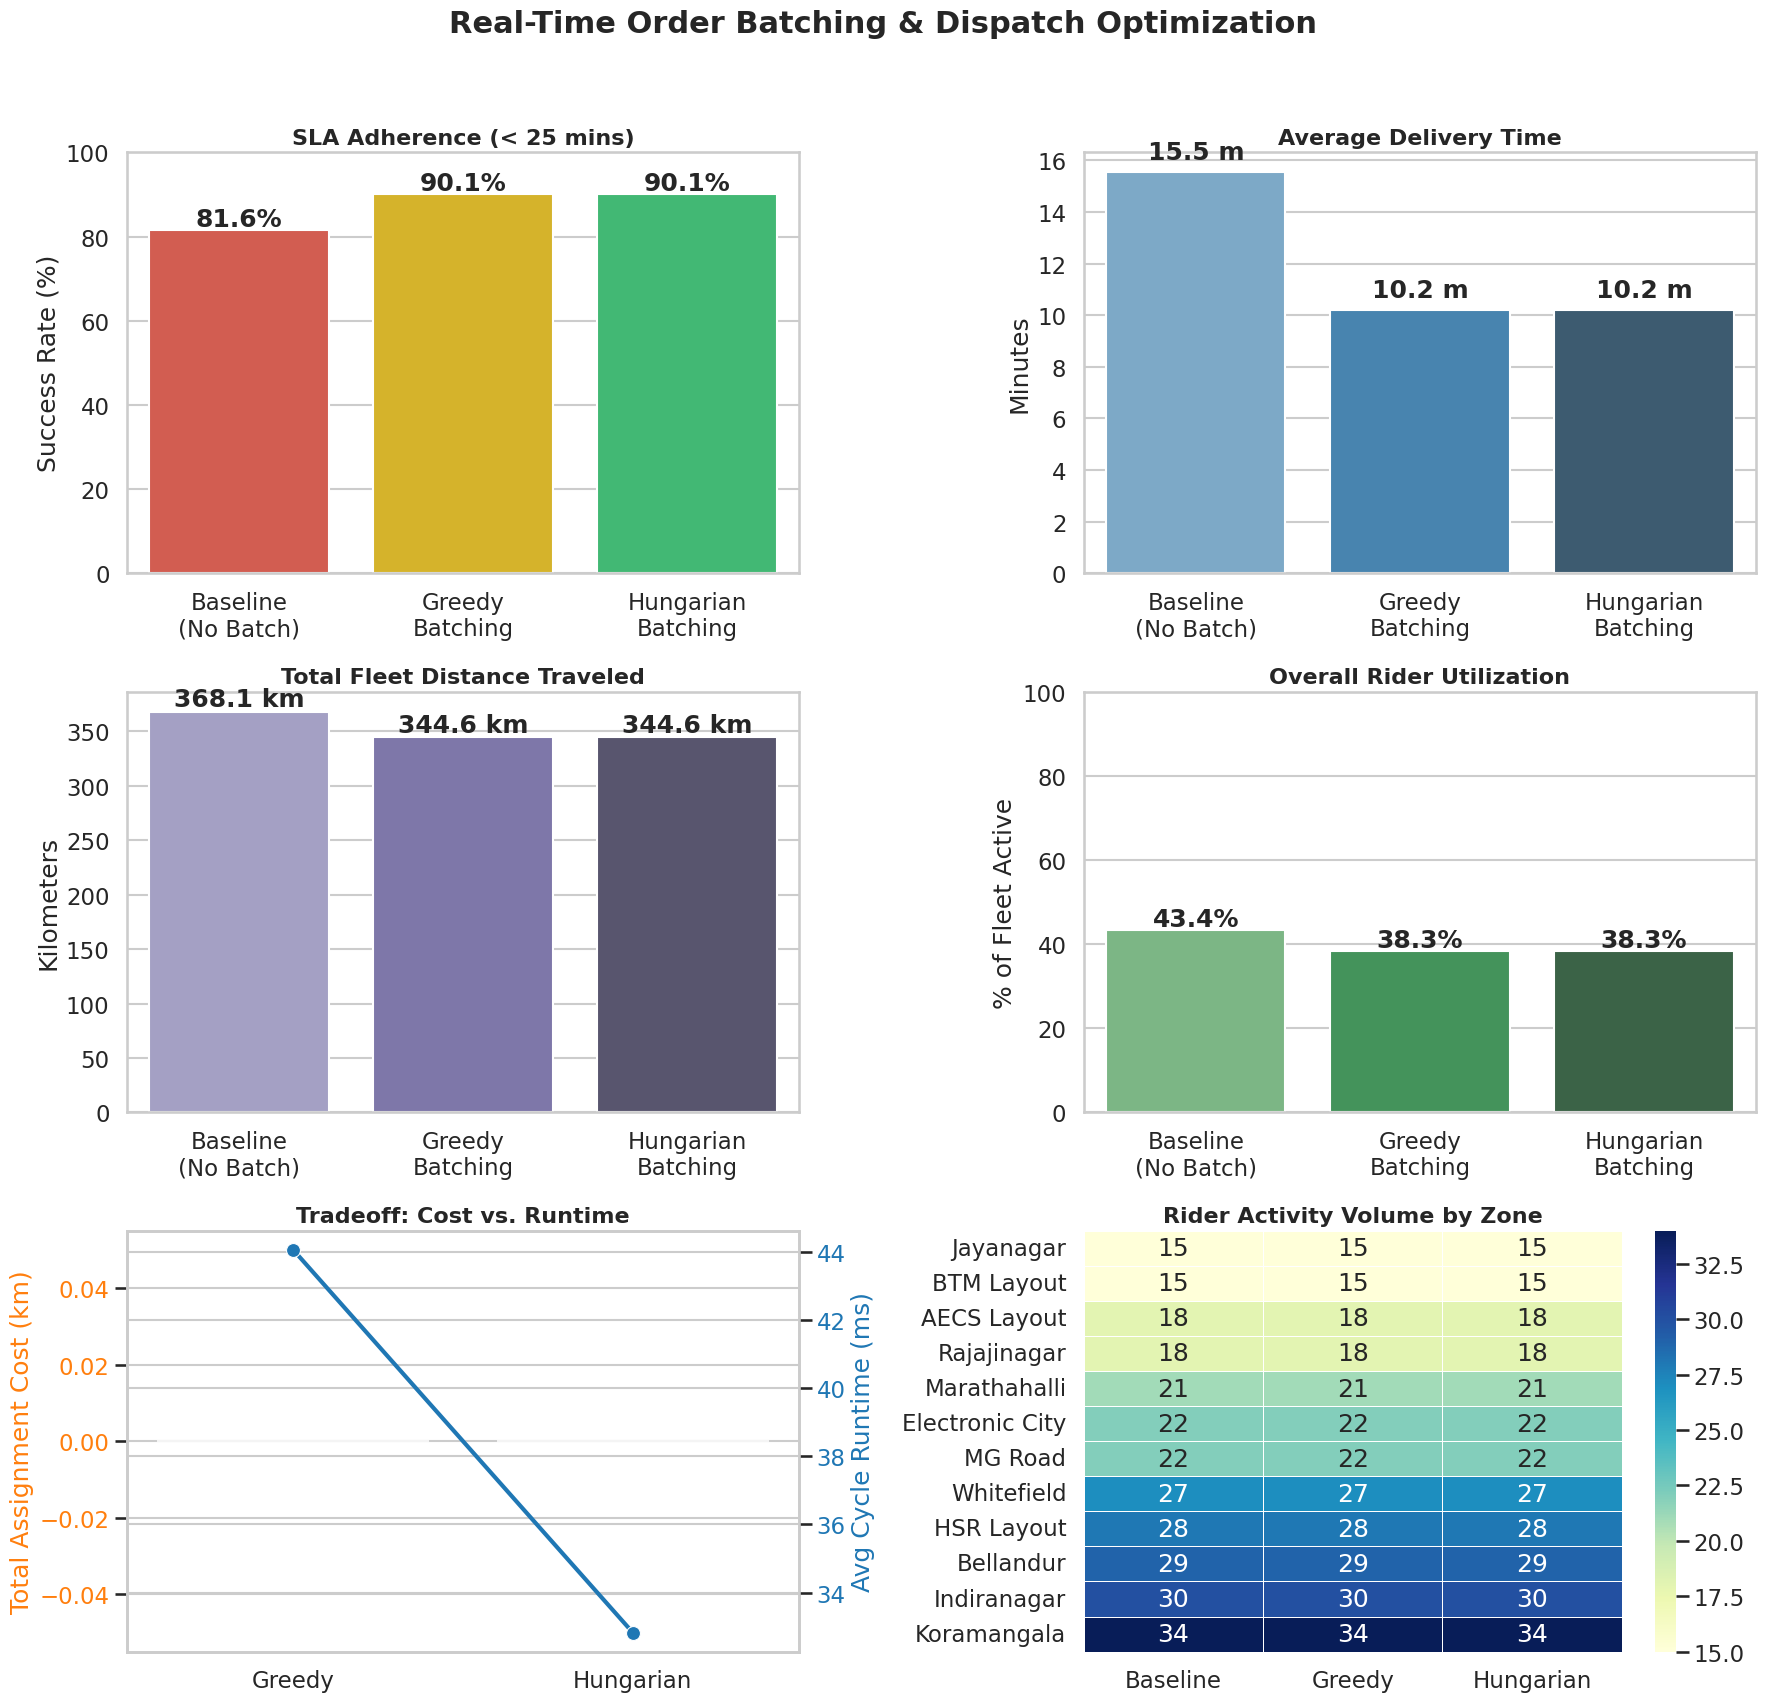

In [47]:
# --- EXECUTION: CALL THE DASHBOARD FUNCTION ---
print("Compiling final dashboard...")

generate_final_report(
    orders_df=orders_df,

    # Baseline outputs (From Cell 3)
    res_baseline=baseline_results,
    fleet_baseline=final_fleet,

    # Greedy outputs (From updated Cell 5/6)
    res_greedy=g_res,
    fleet_greedy=g_fleet,
    greedy_assign_times=g_time,
    greedy_assign_costs=g_cost,

    # Hungarian outputs (From updated Cell 5/6)
    res_hungarian=h_res,
    fleet_hungarian=h_fleet,
    hungarian_assign_times=h_time,
    hungarian_assign_costs=h_cost
)